# Training a GAN Model with Cifar10


In [34]:
from tensorflow import keras
from keras import layers
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import cv2

### Load the data into training and testing sets

In [5]:
from keras.datasets import cifar10

#load dataset
cifar10 = tf.keras.datasets.cifar10.load_data()
(X_train_full, y_train_full), (X_test, y_test) = cifar10

#normalize images
X_train_full = X_train_full.astype(np.float32) / 255
X_test = X_test.astype(np.float32) / 255

#split into training and validation
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

In [6]:
np.unique(y_train) #labels are 0 to 9, 10 classes total

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [7]:
X_train.shape #images are 32x32x3

(45000, 32, 32, 3)

In [8]:
X_test.shape

(10000, 32, 32, 3)

(-0.5, 31.5, 31.5, -0.5)

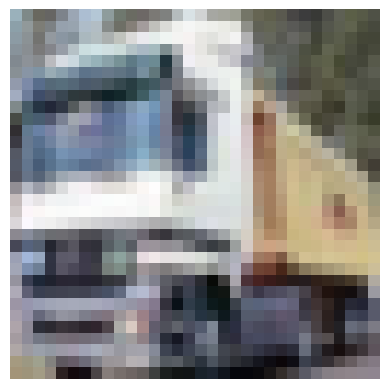

In [9]:
X_train[1]

plt.imshow(X_train[1])
plt.axis("off")

In [10]:
#convert to grayscale
X_train = tf.image.rgb_to_grayscale(X_train).numpy()
X_valid = tf.image.rgb_to_grayscale(X_valid).numpy()
X_test = tf.image.rgb_to_grayscale(X_test).numpy()

In [11]:
X_train.shape #1 channel because it is grayscale

(45000, 32, 32, 1)

(-0.5, 31.5, 31.5, -0.5)

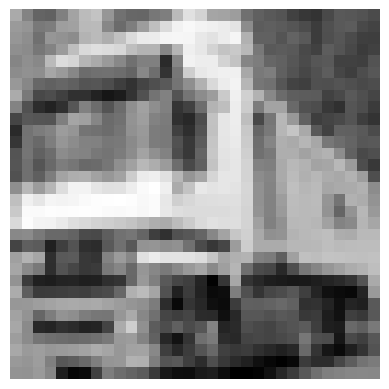

In [12]:
plt.imshow(X_train[1, :, :, 0], cmap='gray')
plt.axis('off')

### Defining Model

In [13]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU

codings_size = 30 #size of the noise vector fed to the generator

generator = tf.keras.Sequential([
    tf.keras.layers.Dense(8 * 8 * 128),
    tf.keras.layers.Reshape([8, 8, 128]),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2DTranspose(64, kernel_size=5, strides=2,
                                    padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2DTranspose(1, kernel_size=5, strides=2,
                                    padding="same", activation="tanh"),
])

In [14]:
discriminator = tf.keras.Sequential([
    tf.keras.layers.Conv2D(64, kernel_size=5, strides=2, padding="same",
                        activation=tf.keras.layers.LeakyReLU(0.2)),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Conv2D(128, kernel_size=5, strides=2, padding="same",
                        activation=tf.keras.layers.LeakyReLU(0.2)),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [15]:
gan = tf.keras.Sequential([generator, discriminator])

### Loss and parameters

In [16]:
discriminator.compile(loss="binary_crossentropy", optimizer="adam")

In [17]:
discriminator.trainable = False #freezing so that weights are not changed

In [18]:
gan.compile(loss="binary_crossentropy", optimizer="adam")

In [19]:
X_train_dcgan = X_train.reshape(-1, 32, 32, 1) * 2. - 1. # reshape and rescale

In [20]:
#creating batches
batch_size = 32
dataset = tf.data.Dataset.from_tensor_slices(X_train_dcgan)
dataset = dataset.shuffle(1000)
dataset = dataset.batch(batch_size, drop_remainder=True).prefetch(1)

### Training GAN

In [28]:
def plot_multiple_images(images, n_cols=None):
    n_cols = n_cols or len(images)
    n_rows = (len(images) - 1) // n_cols + 1

    if images.shape[-1] == 1:
        images = images.squeeze(axis=-1)
    plt.figure(figsize=(n_cols, n_rows))

    for index, image in enumerate(images):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(image, cmap="gray")
        plt.axis("off")
    plt.show()

In [29]:
def train_gan(gan, dataset, batch_size, codings_size, n_epochs):
    """
    Trains a GAN for a fixed number of epochs.
    """
    generator, discriminator = gan.layers
    for epoch in range(n_epochs):
        print(f"Epoch {epoch + 1}/{n_epochs}")
        for X_batch in dataset:
            # Phase 1 - training the discriminator
            noise = tf.random.normal(shape=[batch_size, codings_size])
            generated_images = generator(noise)

            X_fake_and_real = tf.concat([generated_images, X_batch], axis=0)
            y1 = tf.constant([[0.]] * batch_size + [[1.]] * batch_size)
            discriminator.train_on_batch(X_fake_and_real, y1)

            # Phase 2 - training the generator
            noise = tf.random.normal(shape=[batch_size, codings_size])
            y2 = tf.constant([[1.]] * batch_size)  # The label for generator is 1, fake labels are real for generator cost
            gan.train_on_batch(noise, y2)

        # Extra code — plot images during training
        plot_multiple_images(generated_images.numpy(), 8)
        plt.show()

Epoch 1/10


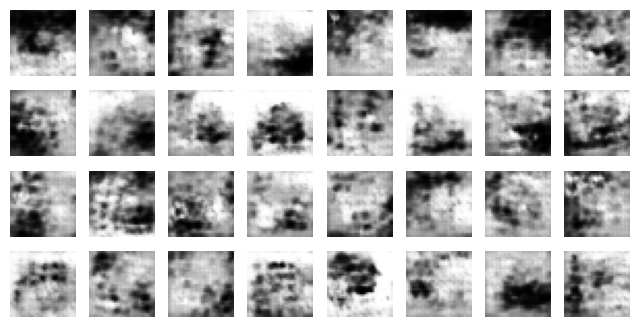

Epoch 2/10


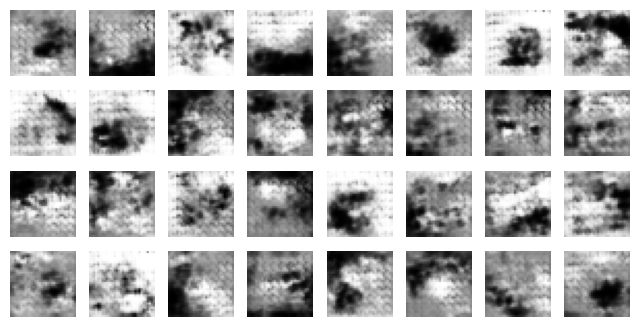

Epoch 3/10


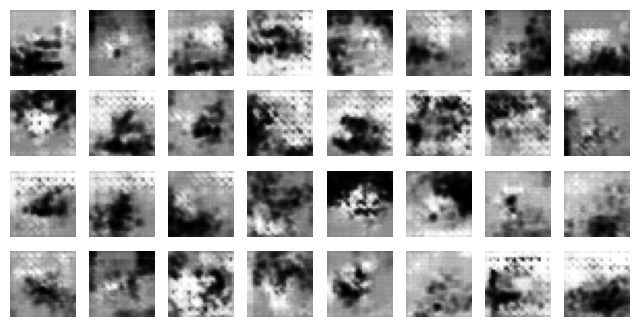

Epoch 4/10


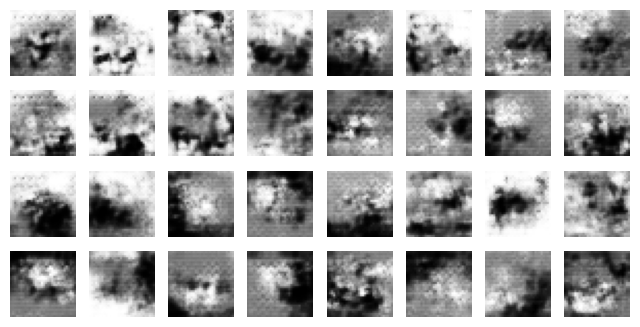

Epoch 5/10


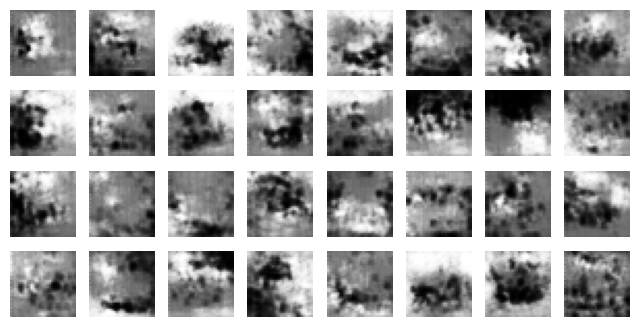

Epoch 6/10


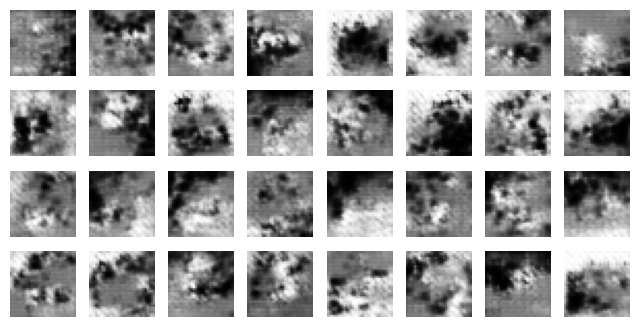

Epoch 7/10


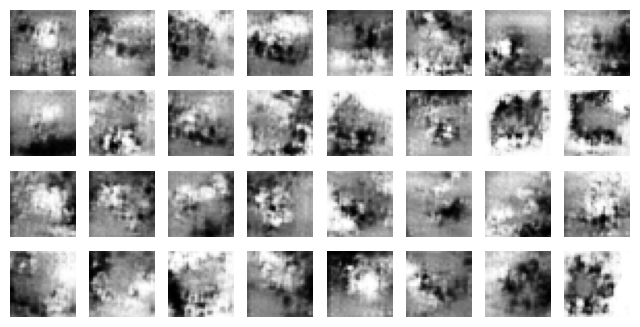

Epoch 8/10


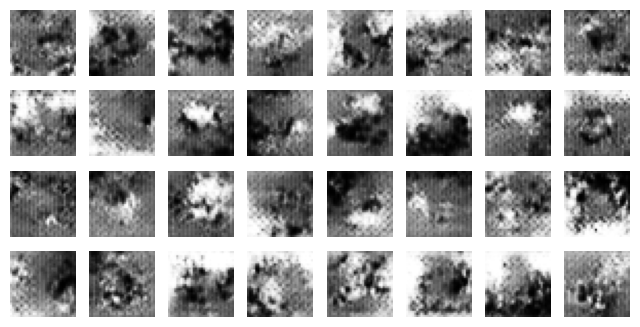

Epoch 9/10


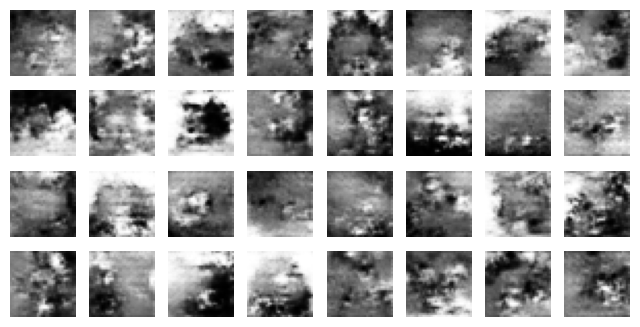

Epoch 10/10


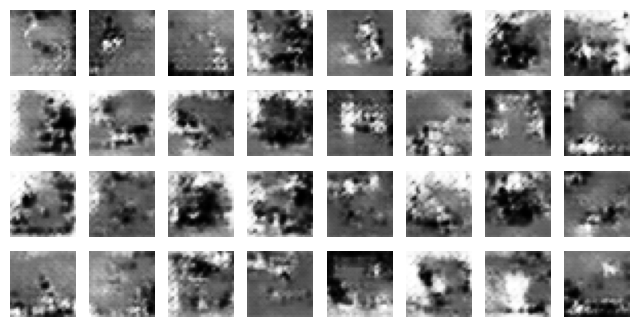

In [30]:
train_gan(gan, dataset, batch_size, codings_size, n_epochs=10)